<a href="https://colab.research.google.com/github/faizijr12github/Linear-Regression-from-scratch/blob/main/Linear_Regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Dataset

In [43]:
import pandas as pd
import seaborn as sns
df = pd.read_csv('/content/placement.csv')
df.sample(5)

,cgpa,package
108,7.76,3.54
16,6.84,2.35
123,5.10,2.30
165,8.21,4.08
97,5.98,2.84


In [44]:
df.shape

(200, 2)

<Axes: xlabel='cgpa', ylabel='package'>

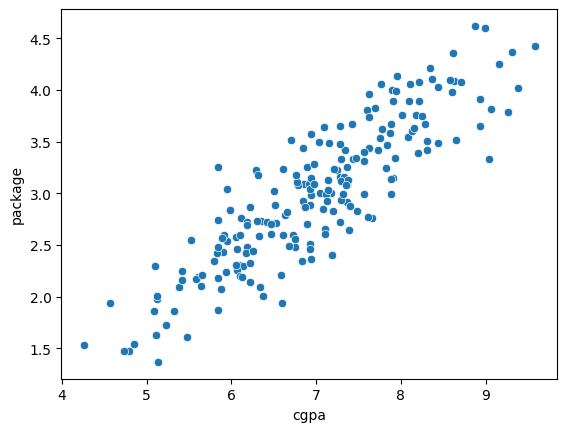

In [45]:
sns.scatterplot(x='cgpa',y='package', data=df)

Observation about data => Data is sort of linear

Simple Linear Regression is about drawing a best fit line with use of m and b

m = slope, weight

b = y-intercept, offset  

In [46]:
class LinearRegression:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0
        den = 0
        x_mean = X_train.mean()
        y_mean = y_train.mean()

        for i in range(X_train.shape[0]):
            num += (X_train[i] - x_mean) * (y_train[i] - y_mean)
            den += (X_train[i] - x_mean) ** 2

        self.m = num / den
        self.b = y_mean - self.m * x_mean

    def predict(self, X_test):
        return self.m * X_test + self.b

In [47]:
from sklearn.model_selection import train_test_split
X = df.iloc[:,0].values
y = df.iloc[:,1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=10)

In [48]:
X_train

array([8.71, 7.43, 6.94, 6.22, 6.87, 8.15, 6.78, 9.31, 6.07, 7.32, 6.19,
       6.75, 8.31, 7.91, 6.92, 7.78, 7.05, 6.22, 5.84, 9.04, 6.53, 7.66,
       6.71, 8.93, 6.85, 5.61, 7.04, 5.79, 7.11, 8.87, 7.39, 8.18, 6.63,
       8.13, 4.57, 7.56, 8.21, 5.84, 6.51, 5.11, 5.23, 8.62, 5.89, 7.3 ,
       6.61, 7.37, 8.44, 8.6 , 7.12, 6.89, 7.63, 6.1 , 6.96, 6.22, 8.63,
       7.28, 6.47, 6.66, 5.38, 7.89, 9.26, 7.73, 5.58, 4.26, 7.88, 7.15,
       7.42, 6.19, 5.66, 7.35, 5.9 , 8.11, 7.84, 6.26, 7.87, 5.84, 5.98,
       7.14, 7.28, 5.95, 7.29, 6.37, 7.18, 7.13, 7.09, 4.85, 8.65, 8.94,
       8.58, 6.61, 6.14, 6.13, 4.79, 6.07, 6.73, 7.93, 8.28, 6.98, 7.57,
       7.62, 7.34, 7.76, 9.58, 7.2 , 6.17, 5.84, 6.94, 6.05, 5.09, 7.11,
       6.29, 5.94, 6.1 , 8.01, 6.19, 7.47, 7.4 , 8.25, 7.21, 7.14, 6.85,
       5.88, 5.83, 6.12, 6.3 , 6.75, 6.79, 6.94, 5.42, 5.99, 6.6 , 8.1 ,
       7.6 , 7.91, 6.42, 5.95, 7.36, 7.61, 7.9 , 6.76, 5.91, 7.94, 6.93,
       8.99, 8.22, 7.28, 6.35, 6.34, 5.12, 6.33, 4.

In [49]:
y_train

array([4.08, 3.33, 3.15, 2.14, 2.87, 3.63, 3.11, 4.37, 2.26, 2.99, 2.69,
       2.48, 3.42, 3.89, 3.09, 3.62, 3.  , 2.33, 2.74, 3.33, 2.71, 2.76,
       3.52, 3.91, 2.93, 2.19, 3.5 , 2.35, 2.66, 4.62, 2.65, 3.76, 2.79,
       3.6 , 1.94, 2.99, 4.08, 1.87, 2.89, 1.63, 1.73, 4.36, 2.57, 3.33,
       3.24, 3.08, 3.49, 3.98, 2.99, 2.7 , 3.44, 2.2 , 3.08, 2.87, 4.09,
       3.65, 2.61, 2.82, 2.09, 3.67, 3.79, 3.42, 2.17, 1.53, 3.14, 3.49,
       3.67, 2.48, 2.21, 3.08, 2.43, 4.06, 3.47, 2.44, 3.58, 2.48, 2.84,
       3.03, 3.48, 2.54, 3.12, 2.01, 3.  , 2.93, 3.64, 1.54, 3.52, 3.65,
       4.1 , 2.6 , 2.3 , 2.19, 1.48, 2.46, 2.6 , 3.34, 3.67, 3.09, 3.4 ,
       3.74, 3.42, 3.54, 4.43, 2.83, 2.42, 2.18, 3.57, 2.58, 1.86, 2.61,
       3.23, 2.24, 2.6 , 3.76, 2.72, 3.34, 2.88, 3.75, 3.24, 3.13, 3.44,
       2.08, 2.42, 2.76, 2.73, 2.56, 3.08, 2.98, 2.16, 2.84, 1.94, 3.89,
       3.81, 3.15, 2.72, 3.04, 3.26, 2.77, 4.  , 3.18, 2.6 , 3.99, 2.89,
       4.6 , 3.89, 2.72, 2.73, 2.09, 2.01, 2.59, 1.

In [50]:
X_train.shape

(170,)

In [51]:
X_train[0]

np.float64(8.71)

In [52]:
y_train[0]

np.float64(4.08)

In [53]:
lr = LinearRegression()
lr.fit(X_train, y_train)

In [54]:
lr.predict(X_train[0])

np.float64(3.97097844573478)

In [55]:
X_test[0]

np.float64(7.56)

In [56]:
y_test[0]

np.float64(3.31)

In [57]:
lr.predict(X_test[0])

np.float64(3.31952445904702)

Text(0, 0.5, 'Package(in lpa)')

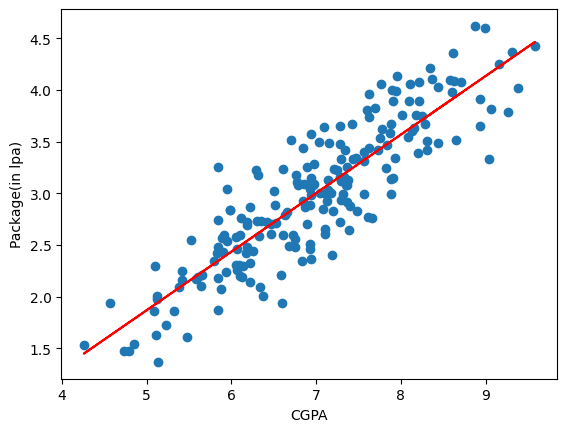

In [60]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')